#Gradient Descent & Optimization

## First step in machine learning training: measuring how wrong the model is.

In [13]:
import numpy as np

# Actual marks scored by students
actual = np.array([50, 60, 70, 80, 90])

# Marks predicted by a simple model
predicted = np.array([52, 58, 75, 78, 88])

# Error = Actual - Predicted
error = actual - predicted

# Squared error
squared_error = error ** 2

# Loss: mean of squared errors
# Mean Squared Error
mse = np.mean(squared_error)

print("Actual values:       ", actual)
print("Predicted values:    ", predicted)
print("Error:               ", error)
print("Squared error:       ", squared_error)
print("Loss(MSE):  ", mse)

Actual values:        [50 60 70 80 90]
Predicted values:     [52 58 75 78 88]
Error:                [-2  2 -5  2  2]
Squared error:        [ 4  4 25  4  4]
Loss(MSE):   8.2


The third prediction has error -5.

After squaring, it becomes 25.

So larger mistakes are punished more.

That is why MSE is sensitive to big errors.

##ML problem:

We are building a model to predict student marks from study hours.

Study hours:  1, 2, 3, 4, 5

Actual marks:  50, 60, 70, 80, 90


`Predicted marks = weight × study hours + bias`

For now, assume:

weight = 8

bias = 40

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Input feature: number of hours studied
study_hours = np.array([1, 2, 3, 4, 5])

# Actual marks scored by students
actual_marks = np.array([50, 60, 70, 80, 90])

# A simple model:
# Predicted marks = weight × study_hours + bias

weight = 8
bias = 40

predicted_marks = weight * study_hours + bias

# Error = Actual - Predicted
error = actual_marks - predicted_marks

# Squared error
squared_error = error ** 2

# Mean Squared Error Loss
mse = np.mean(squared_error)

print("Study hours:        ", study_hours)
print("Actual marks:       ", actual_marks)
print("Predicted marks:    ", predicted_marks)
print("Error:              ", error)
print("Squared error:      ", squared_error)
print("Loss (MSE):         ", mse)

Study hours:         [1 2 3 4 5]
Actual marks:        [50 60 70 80 90]
Predicted marks:     [48 56 64 72 80]
Error:               [ 2  4  6  8 10]
Squared error:       [  4  16  36  64 100]
Loss (MSE):          44.0


What if the weight was different?

    Keep bias fixed at 40 for now.

Try many weights:

    weight = 0, 1, 2, 3, ..., 20

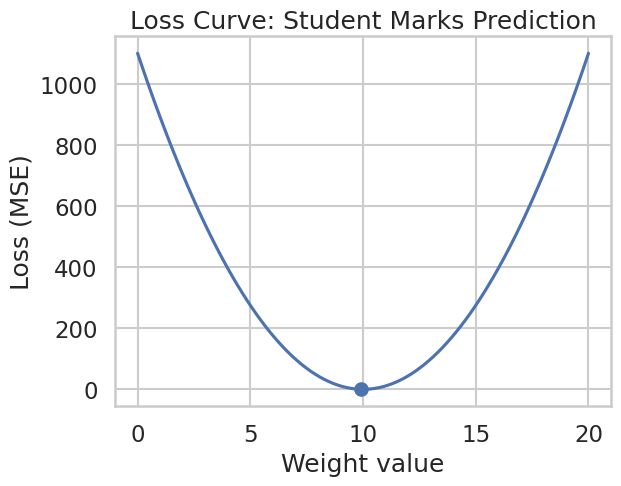

Best weight approximately: 9.9
Minimum loss approximately: 0.1122


In [15]:
# We will keep bias fixed for now
bias = 40

# Try different possible weight values
weights = np.linspace(0, 20, 100)

losses = []

for w in weights:
    # Prediction using current weight
    predicted_marks = w * study_hours + bias

    # Error
    error = actual_marks - predicted_marks

    # MSE Loss
    mse = np.mean(error ** 2)

    losses.append(mse)

# Find the weight with the lowest loss
best_index = np.argmin(losses)
best_weight = weights[best_index]
best_loss = losses[best_index]

# Plot the loss curve
plt.plot(weights, losses)
plt.scatter(best_weight, best_loss)

plt.xlabel("Weight value")
plt.ylabel("Loss (MSE)")
plt.title("Loss Curve: Student Marks Prediction")
plt.show()

print("Best weight approximately:", round(best_weight, 2))
print("Minimum loss approximately:", round(best_loss, 4))

They should see the lowest point near:

weight = 10

So the loss becomes almost zero.

So now we tried many possible weight values.

- For every weight, the model predicts marks.

- For every prediction, we calculate error and loss.

- When we plot weight against loss, we get the loss curve.
- The bottom of the curve tells us the weight value where loss is lowest.


##Understanding Learning Rate

Learning rate controls how big each gradient descent step is.

But in real training, the model does not try every possible weight manually.

Instead, it starts with one weight, checks the gradient, and updates step by step.

The **learning rate** decides how big each step should be.

Remember:

- **Gradient** = direction signal
- **Learning rate** = step size

`New weight = Old weight - Learning rate × Gradient`

In [16]:
import numpy as np

study_hours = np.array([1, 2, 3, 4, 5], dtype=float)
actual_marks = np.array([50, 60, 70, 80, 90], dtype=float)

bias = 40
weight = 0
learning_rate = 0.03
epochs = 15
n = len(study_hours)

print("Goal: Learn a weight close to 10")
print("-" * 90)

for epoch in range(1, epochs + 1):
    # Predict using current weight
    predicted_marks = weight * study_hours + bias

    # Calculate error and loss
    error = actual_marks - predicted_marks
    loss = np.mean(error ** 2)

    # Calculate gradient
    gradient = (-2 / n) * np.sum(study_hours * error)

    # Calculate new weight
    new_weight = weight - learning_rate * gradient

    print(
        f"Epoch {epoch:02d} | "
        f"Old Weight: {weight:8.5f} | "
        f"Loss: {loss:10.8f} | "
        f"Gradient: {gradient:10.6f} | "
        f"New Weight: {new_weight:8.5f}"
    )

    weight = new_weight

Goal: Learn a weight close to 10
------------------------------------------------------------------------------------------
Epoch 01 | Old Weight:  0.00000 | Loss: 1100.00000000 | Gradient: -220.000000 | New Weight:  6.60000
Epoch 02 | Old Weight:  6.60000 | Loss: 127.16000000 | Gradient: -74.800000 | New Weight:  8.84400
Epoch 03 | Old Weight:  8.84400 | Loss: 14.69969600 | Gradient: -25.432000 | New Weight:  9.60696
Epoch 04 | Old Weight:  9.60696 | Loss: 1.69928486 | Gradient:  -8.646880 | New Weight:  9.86637
Epoch 05 | Old Weight:  9.86637 | Loss: 0.19643733 | Gradient:  -2.939939 | New Weight:  9.95456
Epoch 06 | Old Weight:  9.95456 | Loss: 0.02270816 | Gradient:  -0.999579 | New Weight:  9.98455
Epoch 07 | Old Weight:  9.98455 | Loss: 0.00262506 | Gradient:  -0.339857 | New Weight:  9.99475
Epoch 08 | Old Weight:  9.99475 | Loss: 0.00030346 | Gradient:  -0.115551 | New Weight:  9.99821
Epoch 09 | Old Weight:  9.99821 | Loss: 0.00003508 | Gradient:  -0.039287 | New Weight:  9.99

At the beginning, weight is far from the correct value.

So the loss is high.

After every epoch, the model updates the weight.

As the weight moves closer to 10, the loss reduces.

###Why loss is 0.0000 but gradient is still negative?

At epoch 9, the loss is printed only up to 4 decimal places:

    Loss: 0.0000

But the actual loss may be something like:

    0.000035

When rounded to 4 decimals, it appears as:

    0.0000

So the model is very close, but not perfectly at the minimum yet.

That is why the gradient is still:

    Gradient: -0.0393

It is small, but not zero.

The loss looks like zero because we are printing only 4 decimal places.

But the gradient tells us that the model is still making a tiny correction.

In real training, we do not wait for perfect zero.

We stop when the loss is low enough or the gradient is very small.

###Add stopping condition

In [17]:
weight = 0
learning_rate = 0.03
epochs = 100
tolerance = 1e-6

for epoch in range(1, epochs + 1):
    predicted_marks = weight * study_hours + bias
    error = actual_marks - predicted_marks
    loss = np.mean(error ** 2)
    gradient = (-2 / n) * np.sum(study_hours * error)

    print(
        f"Epoch {epoch:02d} | "
        f"Weight: {weight:8.5f} | "
        f"Loss: {loss:10.8f} | "
        f"Gradient: {gradient:10.6f}"
    )

    if loss < tolerance:
        print("Stopping early: loss is small enough.")
        break

    weight = weight - learning_rate * gradient

Epoch 01 | Weight:  0.00000 | Loss: 1100.00000000 | Gradient: -220.000000
Epoch 02 | Weight:  6.60000 | Loss: 127.16000000 | Gradient: -74.800000
Epoch 03 | Weight:  8.84400 | Loss: 14.69969600 | Gradient: -25.432000
Epoch 04 | Weight:  9.60696 | Loss: 1.69928486 | Gradient:  -8.646880
Epoch 05 | Weight:  9.86637 | Loss: 0.19643733 | Gradient:  -2.939939
Epoch 06 | Weight:  9.95456 | Loss: 0.02270816 | Gradient:  -0.999579
Epoch 07 | Weight:  9.98455 | Loss: 0.00262506 | Gradient:  -0.339857
Epoch 08 | Weight:  9.99475 | Loss: 0.00030346 | Gradient:  -0.115551
Epoch 09 | Weight:  9.99821 | Loss: 0.00003508 | Gradient:  -0.039287
Epoch 10 | Weight:  9.99939 | Loss: 0.00000406 | Gradient:  -0.013358
Epoch 11 | Weight:  9.99979 | Loss: 0.00000047 | Gradient:  -0.004542
Stopping early: loss is small enough.


Let us make it a little more interesting

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Better visual theme
sns.set_theme(style="whitegrid", context="talk")

# -----------------------------------
# Student marks example
# -----------------------------------

study_hours = np.array([1, 2, 3, 4, 5], dtype=float)
actual_marks = np.array([50, 60, 70, 80, 90], dtype=float)

# Model:
# predicted_marks = weight * study_hours + bias
# To keep learning rate explanation simple, keep bias fixed
bias = 40

# Ideal weight is close to 10
# Because:
# 1 hour  -> 50 marks
# 2 hours -> 60 marks
# 3 hours -> 70 marks

def compute_loss(weight):
    predicted_marks = weight * study_hours + bias
    error = actual_marks - predicted_marks
    loss = np.mean(error ** 2)
    return loss

def compute_gradient(weight):
    predicted_marks = weight * study_hours + bias
    error = actual_marks - predicted_marks
    n = len(study_hours)

    # Gradient of MSE loss with respect to weight
    gradient = (-2 / n) * np.sum(study_hours * error)
    return gradient

def run_gradient_descent(start_weight, learning_rate, epochs):
    weight = start_weight

    history = []

    for epoch in range(epochs):
        loss = compute_loss(weight)
        gradient = compute_gradient(weight)

        history.append({
            "epoch": epoch,
            "weight": weight,
            "loss": loss,
            "gradient": gradient,
            "learning_rate": learning_rate
        })

        # Gradient Descent update rule
        weight = weight - learning_rate * gradient

    return pd.DataFrame(history)

Run Gradient Descent for 3 Learning Rates

In [19]:
learning_rates = [0.001, 0.03, 0.08]

start_weight = 0
epochs = 12

gd_results = []

for lr in learning_rates:
    df_lr = run_gradient_descent(
        start_weight=start_weight,
        learning_rate=lr,
        epochs=epochs
    )
    gd_results.append(df_lr)

gd_df = pd.concat(gd_results, ignore_index=True)

gd_df.head()

,epoch,weight,loss,gradient,learning_rate
0,0,0.000000,1100.000000,-220.000000,0.001
1,1,0.220000,1052.132400,-215.160000,0.001
2,2,0.435160,1006.347806,-210.426480,0.001
3,3,0.645586,962.555575,-205.797097,0.001
4,4,0.851384,920.669007,-201.269561,0.001


Plot 1: Loss Curve + Gradient Descent Path

Loss landscape + movement path for different learning rates

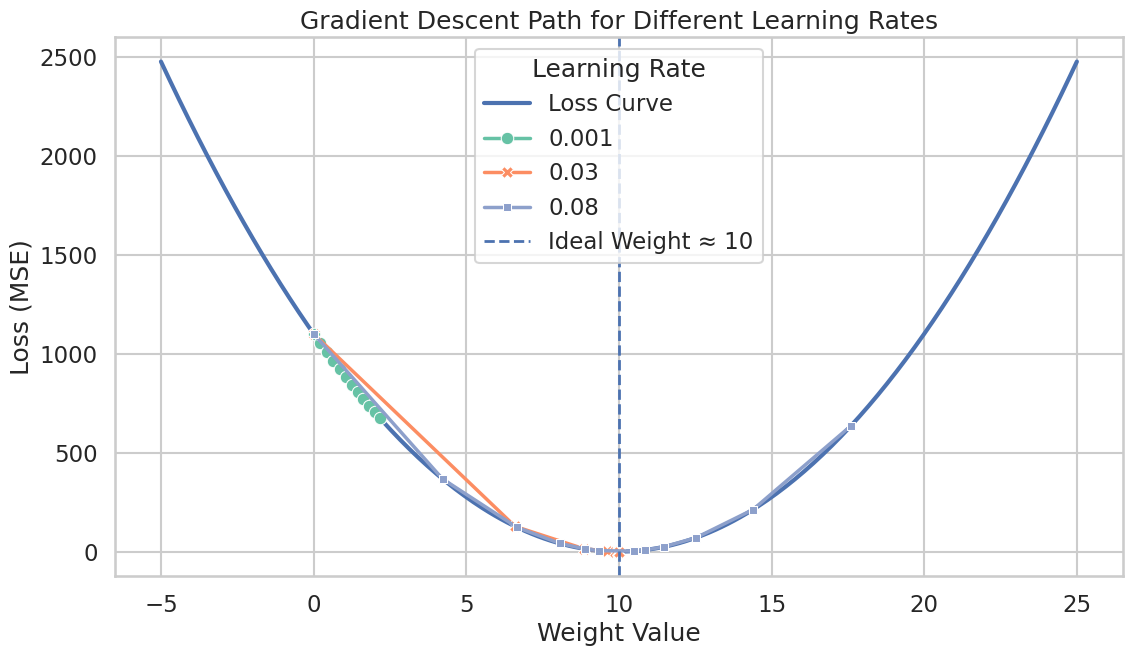

In [20]:
# -----------------------------------
# Create loss curve
# -----------------------------------

weights_for_curve = np.linspace(-5, 25, 300)
losses_for_curve = [compute_loss(w) for w in weights_for_curve]

loss_curve_df = pd.DataFrame({
    "weight": weights_for_curve,
    "loss": losses_for_curve
})

# -----------------------------------
# Plot using Seaborn
# -----------------------------------

plt.figure(figsize=(13, 7))

# Loss curve
sns.lineplot(
    data=loss_curve_df,
    x="weight",
    y="loss",
    linewidth=3,
    label="Loss Curve"
)

# Gradient descent paths
sns.lineplot(
    data=gd_df,
    x="weight",
    y="loss",
    hue="learning_rate",
    style="learning_rate",
    markers=True,
    dashes=False,
    linewidth=2.5,
    markersize=9,
    palette="Set2"
)

# Mark ideal weight
plt.axvline(
    x=10,
    linestyle="--",
    linewidth=2,
    label="Ideal Weight ≈ 10"
)

plt.title("Gradient Descent Path for Different Learning Rates")
plt.xlabel("Weight Value")
plt.ylabel("Loss (MSE)")
plt.legend(title="Learning Rate")
plt.show()

The smooth curve is the loss landscape.

- The x-axis shows different weight values.

- The y-axis shows the loss for each weight.

- The lowest point is near weight = 10.

Now look at the colored paths.

Each dot is one gradient descent update step.

- For learning rate 0.001, the steps are very tiny.
The model is moving correctly, but very slowly.

- For learning rate 0.03, the movement is balanced.
It reaches the low-loss region quickly.

- For learning rate 0.08, the step is large.
It jumps around the minimum before settling.
This is overshooting.

Plot: Loss vs Epoch

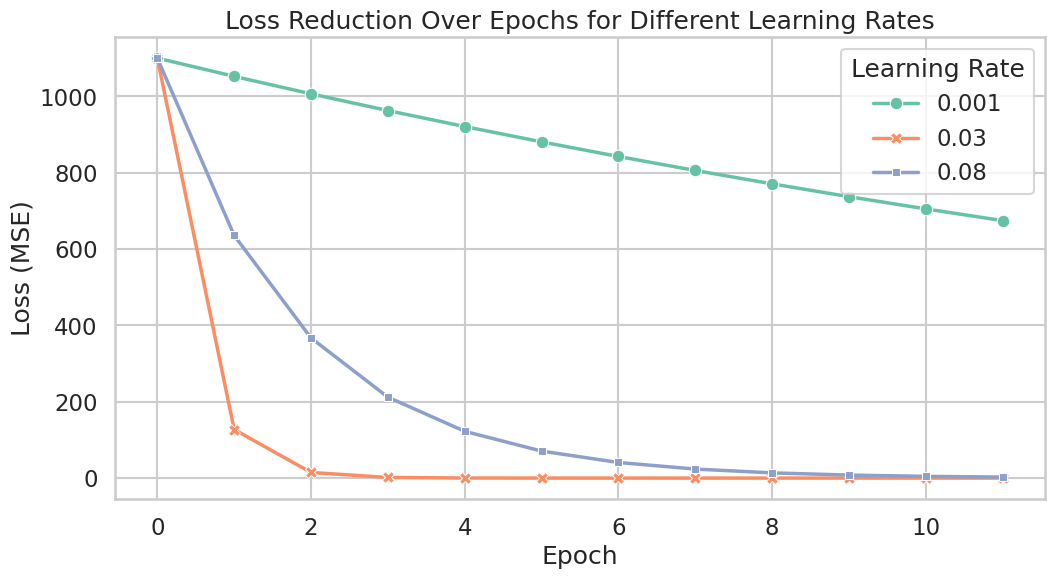

In [21]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=gd_df,
    x="epoch",
    y="loss",
    hue="learning_rate",
    style="learning_rate",
    markers=True,
    dashes=False,
    linewidth=2.5,
    markersize=9,
    palette="Set2"
)

plt.title("Loss Reduction Over Epochs for Different Learning Rates")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend(title="Learning Rate")
plt.show()

Plot 3: Weight Movement Over Epochs

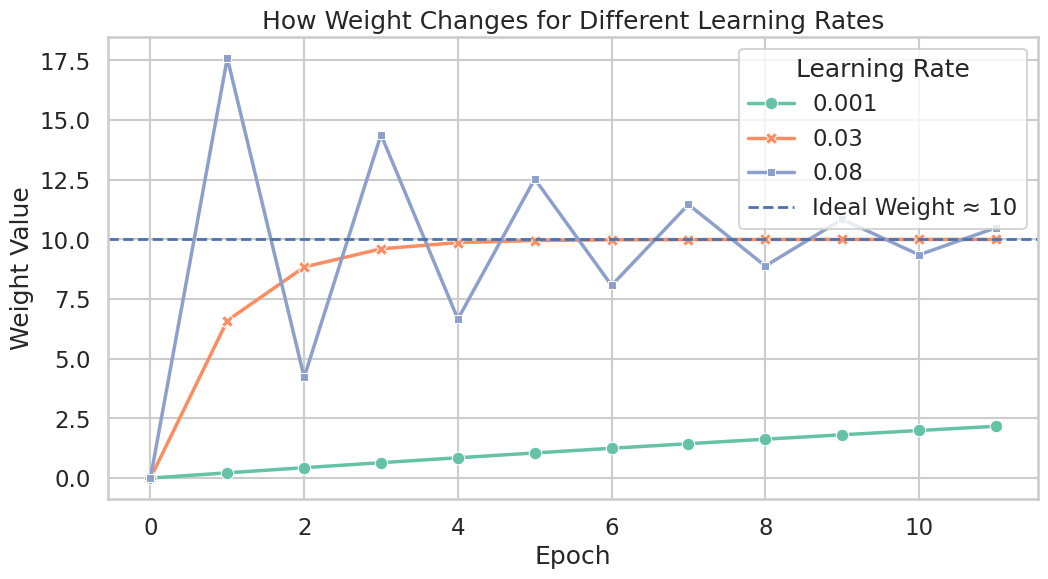

In [22]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=gd_df,
    x="epoch",
    y="weight",
    hue="learning_rate",
    style="learning_rate",
    markers=True,
    dashes=False,
    linewidth=2.5,
    markersize=9,
    palette="Set2"
)

plt.axhline(
    y=10,
    linestyle="--",
    linewidth=2,
    label="Ideal Weight ≈ 10"
)

plt.title("How Weight Changes for Different Learning Rates")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.legend(title="Learning Rate")
plt.show()

The correct weight is around 10.

- Learning rate 0.001 moves toward 10 very slowly.

- Learning rate 0.03 reaches close to 10 quickly.

- Learning rate 0.08 jumps beyond 10 and comes back.
That means the step size is large.

#Batch GD vs SGD vs Mini-Batch GD

We will use the same problem:

  Predict student marks from study hours.

But now instead of 5 students, we create 100 students.

The true pattern is approximately:

  `marks = 10 × study_hours + 40`

For simplicity, we will keep:

  bias = 40 fixed

  Only weight will be learned

This keeps the focus on Batch vs SGD vs Mini-Batch, not on too many parameters.

##Create Dataset

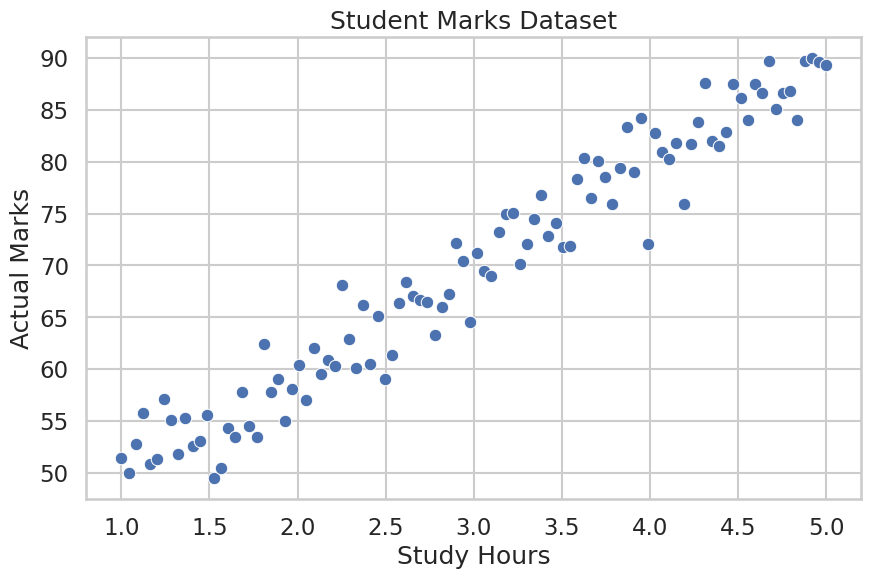

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

# Reproducibility
np.random.seed(42)

# Create a larger student dataset
# Study hours from 1 to 5
study_hours = np.linspace(1, 5, 100)

# Actual marks follow a pattern: marks = 10 * hours + 40 + small noise
noise = np.random.normal(0, 3, size=study_hours.shape)
actual_marks = 10 * study_hours + 40 + noise

# Keep bias fixed for this demo
bias = 40

# Visualize the data
plt.figure(figsize=(10, 6))
sns.scatterplot(x=study_hours, y=actual_marks)
plt.xlabel("Study Hours")
plt.ylabel("Actual Marks")
plt.title("Student Marks Dataset")
plt.show()

Loss and Gradient Functions

- Loss tells us how bad the current weight is.

- Gradient tells us how the weight should change to reduce loss.

In [24]:
def compute_loss(weight, x, y, bias=40):
    """
    Calculates Mean Squared Error loss.
    """
    predictions = weight * x + bias
    error = y - predictions
    loss = np.mean(error ** 2)
    return loss


def compute_gradient(weight, x, y, bias=40):
    """
    Calculates gradient of MSE loss with respect to weight.
    """
    predictions = weight * x + bias
    error = y - predictions
    n = len(x)

    gradient = (-2 / n) * np.sum(x * error)
    return gradient

Batch Gradient Descent: Batch GD looks at all 100 students, calculates one gradient, and makes one update.

In [25]:
def batch_gradient_descent(x, y, learning_rate=0.03, epochs=30, start_weight=0):
    weight = start_weight
    history = []

    for epoch in range(epochs):
        loss = compute_loss(weight, x, y, bias)
        gradient = compute_gradient(weight, x, y, bias)

        history.append({
            "epoch": epoch,
            "update_number": epoch,
            "weight": weight,
            "loss": loss,
            "method": "Batch GD"
        })

        # One update after using all data
        weight = weight - learning_rate * gradient

    return pd.DataFrame(history)

Stochastic Gradient Descent:

SGD uses one student at a time.

It updates very frequently.

But because each update is based on one student only, the path can be noisy.

In [26]:
def stochastic_gradient_descent(x, y, learning_rate=0.03, epochs=30, start_weight=0):
    weight = start_weight
    history = []
    update_number = 0

    n = len(x)

    for epoch in range(epochs):
        # Shuffle data every epoch
        indices = np.random.permutation(n)

        for i in indices:
            xi = x[i:i+1]
            yi = y[i:i+1]

            loss = compute_loss(weight, x, y, bias)  # full loss for monitoring
            gradient = compute_gradient(weight, xi, yi, bias)

            history.append({
                "epoch": epoch,
                "update_number": update_number,
                "weight": weight,
                "loss": loss,
                "method": "SGD"
            })

            # One update after one data point
            weight = weight - learning_rate * gradient
            update_number += 1

    return pd.DataFrame(history)

Mini-Batch Gradient Descent

Mini-Batch GD uses a small group of students before one update.

This is more stable than SGD and faster than Batch GD.

In [27]:
def mini_batch_gradient_descent(x, y, learning_rate=0.03, epochs=30, batch_size=16, start_weight=0):
    weight = start_weight
    history = []
    update_number = 0

    n = len(x)

    for epoch in range(epochs):
        # Shuffle data every epoch
        indices = np.random.permutation(n)

        for start in range(0, n, batch_size):
            batch_indices = indices[start:start + batch_size]

            xb = x[batch_indices]
            yb = y[batch_indices]

            loss = compute_loss(weight, x, y, bias)  # full loss for monitoring
            gradient = compute_gradient(weight, xb, yb, bias)

            history.append({
                "epoch": epoch,
                "update_number": update_number,
                "weight": weight,
                "loss": loss,
                "method": "Mini-Batch GD"
            })

            # One update after one mini-batch
            weight = weight - learning_rate * gradient
            update_number += 1

    return pd.DataFrame(history)

Run All Three Methods

The learning rates are slightly different because SGD and Mini-Batch update more frequently.

If we use the same learning rate for every method, SGD may jump too much.

In [28]:
batch_df = batch_gradient_descent(
    study_hours,
    actual_marks,
    learning_rate=0.03,
    epochs=30,
    start_weight=0
)

sgd_df = stochastic_gradient_descent(
    study_hours,
    actual_marks,
    learning_rate=0.003,
    epochs=30,
    start_weight=0
)

mini_batch_df = mini_batch_gradient_descent(
    study_hours,
    actual_marks,
    learning_rate=0.01,
    epochs=30,
    batch_size=16,
    start_weight=0
)

all_methods_df = pd.concat(
    [batch_df, sgd_df, mini_batch_df],
    ignore_index=True
)

all_methods_df.head()

,epoch,update_number,weight,loss,method
0,0,0,0.000000,1027.594703,Batch GD
1,1,1,6.168528,153.452772,Batch GD
2,2,2,8.502599,28.298087,Batch GD
3,3,3,9.385774,10.379149,Batch GD
4,4,4,9.719953,7.813617,Batch GD


Plot Loss vs Update Number

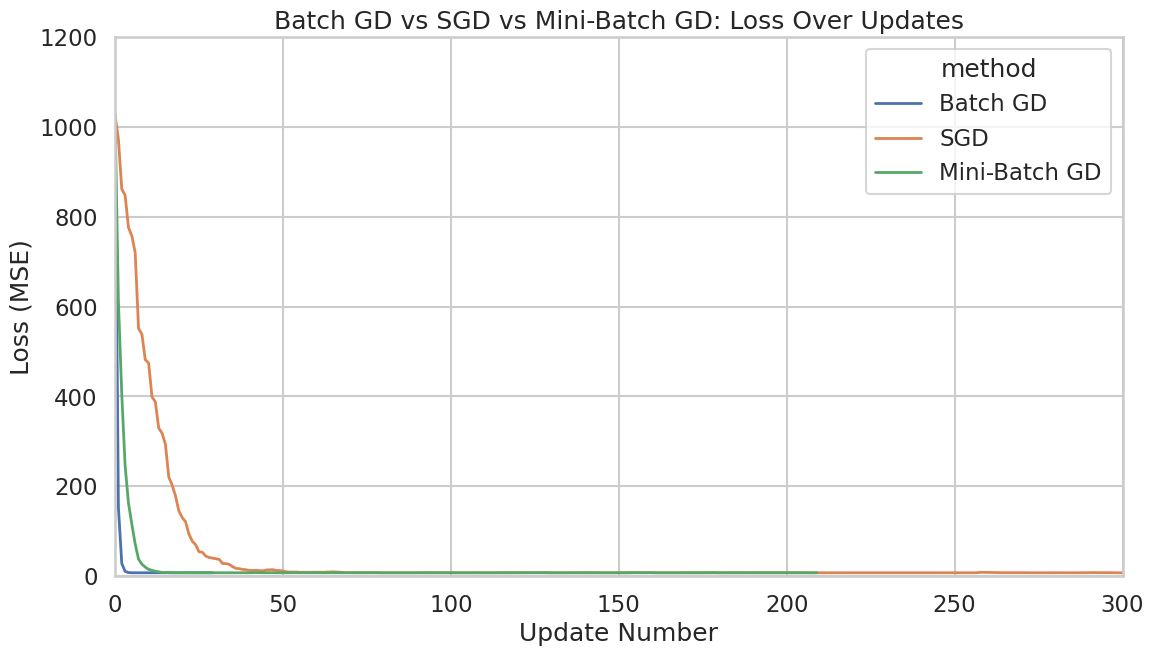

In [31]:
plt.figure(figsize=(13, 7))

sns.lineplot(
    data=all_methods_df,
    x="update_number",
    y="loss",
    hue="method",
    linewidth=2
)

plt.xlabel("Update Number")
plt.ylabel("Loss (MSE)")
plt.title("Batch GD vs SGD vs Mini-Batch GD: Loss Over Updates")
plt.ylim(0, 1200)
plt.xlim(0,300)
plt.show()

Batch GD has fewer updates and smoother behavior.

SGD has many updates and can look noisy.

Mini-Batch GD is a balance.

It updates more often than Batch GD,
but is less noisy than SGD.